In [46]:
# section 1: importing dependencies
import pandas as pd                               # Data manipulation
import matplotlib.pyplot as plt                   # Visualisation
# import seaborn as sn                              # Heatmap for confusion matrix
import numpy as np                                # Numerical operations
from sklearn.datasets import load_iris            # Iris dataset
from sklearn.model_selection import train_test_split  # Data splitting
from sklearn.neighbors import KNeighborsClassifier    # KNN classifier
from sklearn.metrics import (                     # Evaluation metrics
    confusion_matrix,
    classification_report
)

# I chose KNeighbourClassifer since this is a classification problem and we will work with discrete classes like setosa/versicolor/
# virginica


In [47]:
# section 2: loading and exploring dataset
iris = load_iris()

print(f"Feature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")

# Create DataFrame for readable exploration
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


In [48]:
df['flower_name'] = df.target.apply(lambda x: iris.target_names[x])

print(f"\nDataset shape: {df.shape[0]} samples, {len(iris.feature_names)} features")
print(f"\nFirst 5 rows:")
print(df.head())

# Inspect each class separately to understand feature distributions
print(f"\nSetosa samples (class 0):")
print(df[df.target == 0].head())
print(f"\nVersicolor samples (class 1):")
print(df[df.target == 1].head())
print(f"\nVirginica samples (class 2):")
print(df[df.target == 2].head())


Dataset shape: 150 samples, 4 features

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target flower_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Setosa samples (class 0):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3     

In [49]:
print(f"\nClass boundary (rows 45-54):")
print(df[45:55])

# Class distribution
print(f"\nClass distribution:")
print(df['flower_name'].value_counts())
print()
# It confirms that classes are stored sequentially setosa,
# versicolor and virginica. This matters for understanding
# why shuffling  is important.


Class boundary (rows 45-54):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
45                4.8               3.0                1.4               0.3   
46                5.1               3.8                1.6               0.2   
47                4.6               3.2                1.4               0.2   
48                5.3               3.7                1.5               0.2   
49                5.0               3.3                1.4               0.2   
50                7.0               3.2                4.7               1.4   
51                6.4               3.2                4.5               1.5   
52                6.9               3.1                4.9               1.5   
53                5.5               2.3                4.0               1.3   
54                6.5               2.8                4.6               1.5   

    target flower_name  
45       0      setosa  
46       0      setosa  
47       0    

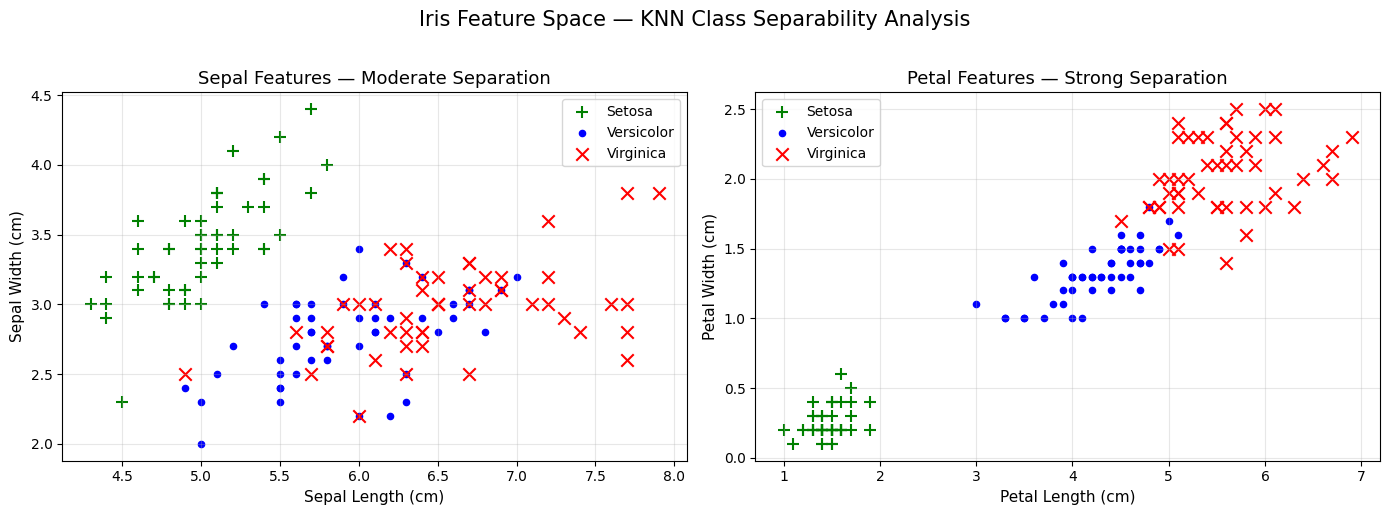

Feature space plot saved to iris_knn_feature_space.png



In [50]:
# Section 3: visualisation of the data
# KNN classifies based on distance to neighbours. We
# can visually assess now how close/far apart classes are by determining KNN's difficulty, whether classes form tight clusters or are spread out or overlapping

# separating data by class for colour coded plotting
df0 = df[df.target == 0]  # Setosa
df1 = df[df.target == 1]  # Versicolor
df2 = df[df.target == 2]  # Virginica

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# this plot shows Sepal Length vs Sepal Width
# Classes overlap significantly in sepal space. KNN using only here
axes[0].scatter(df0['sepal length (cm)'], df0['sepal width (cm)'],
                color="green", marker='+', label='Setosa', s=80)
axes[0].scatter(df1['sepal length (cm)'], df1['sepal width (cm)'],
                color="blue", marker='.', label='Versicolor', s=80)
axes[0].scatter(df2['sepal length (cm)'], df2['sepal width (cm)'],
                color="red", marker='x', label='Virginica', s=80)
axes[0].set_xlabel('Sepal Length (cm)', fontsize=11)
axes[0].set_ylabel('Sepal Width (cm)', fontsize=11)
axes[0].set_title('Sepal Features — Moderate Separation', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# This plot shows Petal Length vs Petal Width . Petal features show much clearer separation. Setosa is
# completely isolated while Versicolor and Virginica have slight overlap.
axes[1].scatter(df0['petal length (cm)'], df0['petal width (cm)'],
                color="green", marker='+', label='Setosa', s=80)
axes[1].scatter(df1['petal length (cm)'], df1['petal width (cm)'],
                color="blue", marker='.', label='Versicolor', s=80)
axes[1].scatter(df2['petal length (cm)'], df2['petal width (cm)'],
                color="red", marker='x', label='Virginica', s=80)
axes[1].set_xlabel('Petal Length (cm)', fontsize=11)
axes[1].set_ylabel('Petal Width (cm)', fontsize=11)
axes[1].set_title('Petal Features — Strong Separation', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Iris Feature Space — KNN Class Separability Analysis',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('iris_knn_feature_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature space plot saved to iris_knn_feature_space.png\n")


In [51]:
# section 4: Train and Test split
X = df.drop(['target', 'flower_name'], axis='columns')
y = df.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")

Training set: 120 samples
Test set:     30 samples


In [52]:
# section 5: train knn classifier
# we are going to store all training data
#  When a new point arrives for prediction, we gonna compute the distance from the new point to every training point, then find k nearest and then take a majority vote among those k classes.
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train) # this simply stores the training data internally.
accuracy_k10 = knn.score(X_test, y_test)
print(f"Test Accuracy (K=10): {accuracy_k10:.4f} ({accuracy_k10*100:.2f}%)")


sample_pred = knn.predict([[4.8, 3.0, 1.5, 0.3]])
print(f"Prediction for [4.8, 3.0, 1.5, 0.3]: class {sample_pred[0]} "
      f"({iris.target_names[sample_pred[0]]})")


Test Accuracy (K=10): 0.9667 (96.67%)
Prediction for [4.8, 3.0, 1.5, 0.3]: class 0 (setosa)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(



Confusion Matrix:
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


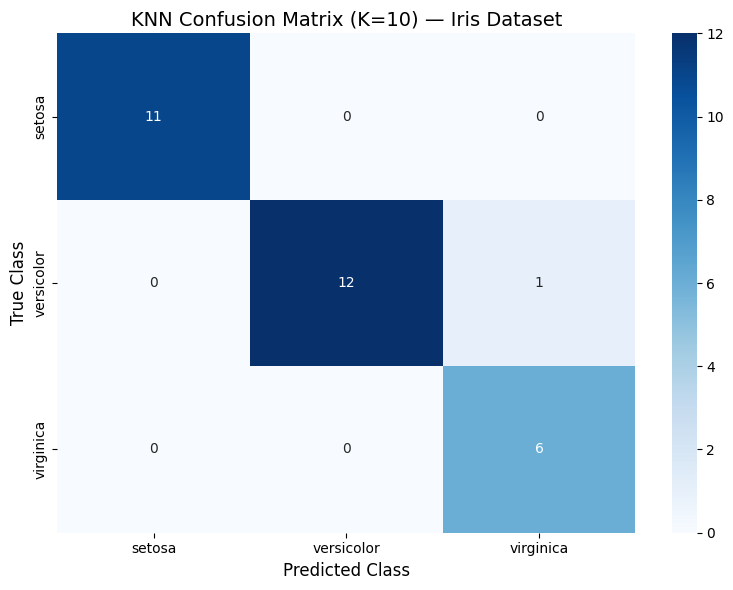

Confusion matrix saved to knn_confusion_matrix_iris.png


In [53]:
# section 6: model evaluation
# while the accuracy tells us the overall percentage of correct predictions, it hides which specific classes the model confusing and if thats better at identifying some classes than the others. Confusion matrix fixes that.
import seaborn as sn
y_pred = knn.predict(X_test)


# Visualise as a heatmap which is much more readable than raw numbers
import seaborn as sn

y_pred = knn.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Heatmap
plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=iris.target_names,
           yticklabels=iris.target_names)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.title('KNN Confusion Matrix (K=10) — Iris Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('knn_confusion_matrix_iris.png', dpi=150)
plt.show()

print("Confusion matrix saved to knn_confusion_matrix_iris.png")


Results for K=1 to K=30:
  K= 1: Accuracy = 1.0000 ◄ BEST
  K= 2: Accuracy = 1.0000
  K= 3: Accuracy = 1.0000
  K= 4: Accuracy = 1.0000
  K= 5: Accuracy = 1.0000
  K= 6: Accuracy = 1.0000
  K= 7: Accuracy = 0.9667
  K= 8: Accuracy = 1.0000
  K= 9: Accuracy = 0.9667
  K=10: Accuracy = 0.9667
  K=11: Accuracy = 0.9667
  K=12: Accuracy = 0.9667
  K=13: Accuracy = 0.9667
  K=14: Accuracy = 0.9667
  K=15: Accuracy = 0.9667
  K=16: Accuracy = 0.9667
  K=17: Accuracy = 0.9667
  K=18: Accuracy = 0.9667
  K=19: Accuracy = 0.9667
  K=20: Accuracy = 0.9667
  K=21: Accuracy = 0.9667
  K=22: Accuracy = 0.9667
  K=23: Accuracy = 0.9667
  K=24: Accuracy = 0.9667
  K=25: Accuracy = 0.9667
  K=26: Accuracy = 0.9667
  K=27: Accuracy = 0.9667
  K=28: Accuracy = 0.9667
  K=29: Accuracy = 0.9667
  K=30: Accuracy = 0.9667

Optimal K = 1 with accuracy = 1.0000 (100.00%)


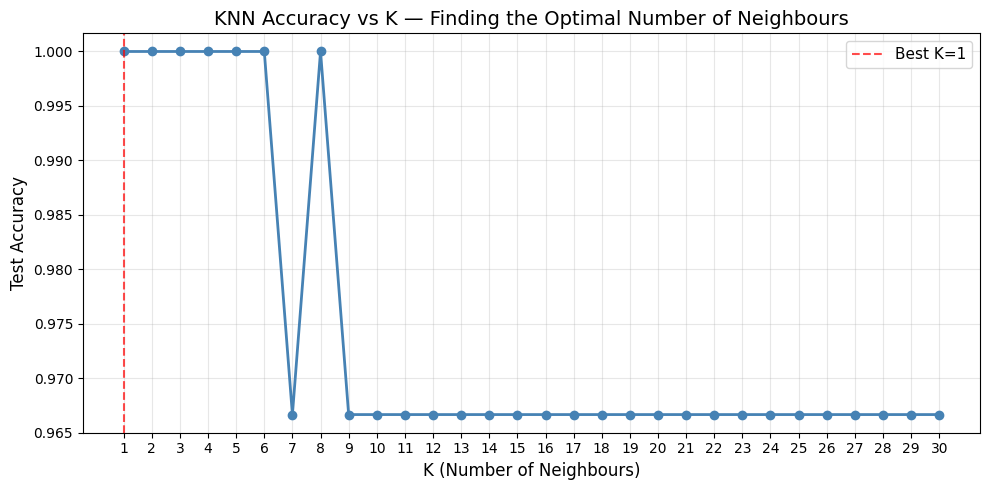

Optimal K plot saved to knn_optimal_k_iris.png



In [54]:
# section 7: finding the optimal k
# K is the single most important hyperparameter in KNN. It controls the bias variance and trade off, we will have either small or large one depending on neighbours. Optimal will be somewhere in between, we will find that by testing multiple values and picking the one with the highest test accuracy
k_values = range(1, 31)  # Test K from 1 to 30
k_accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc = knn_k.score(X_test, y_test)
    k_accuracies.append(acc)

# Find the best K
best_k = k_values[np.argmax(k_accuracies)]
best_acc = max(k_accuracies)

print(f"\nResults for K=1 to K=30:")
for k, acc in zip(k_values, k_accuracies):
    marker = " ◄ BEST" if k == best_k else ""
    print(f"  K={k:>2}: Accuracy = {acc:.4f}{marker}")

print(f"\nOptimal K = {best_k} with accuracy = {best_acc:.4f} ({best_acc*100:.2f}%)")

# Plot accuracy vs K — the "elbow" in this curve reveals the optimal K
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), k_accuracies, 'o-', linewidth=2, markersize=6,
         color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
            label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbours)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('KNN Accuracy vs K — Finding the Optimal Number of Neighbours',
          fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 31))
plt.tight_layout()
plt.savefig('knn_optimal_k_iris.png', dpi=150)
plt.show()
print("Optimal K plot saved to knn_optimal_k_iris.png\n")


Digits dataset shape: (1797, 64)
Number of classes:    10
Image dimensions:     8x8 pixels = 64 features
Pixel value range:    [0, 16]

Samples per digit:
  Digit 0: 178 samples
  Digit 1: 182 samples
  Digit 2: 177 samples
  Digit 3: 183 samples
  Digit 4: 181 samples
  Digit 5: 182 samples
  Digit 6: 181 samples
  Digit 7: 179 samples
  Digit 8: 174 samples
  Digit 9: 180 samples


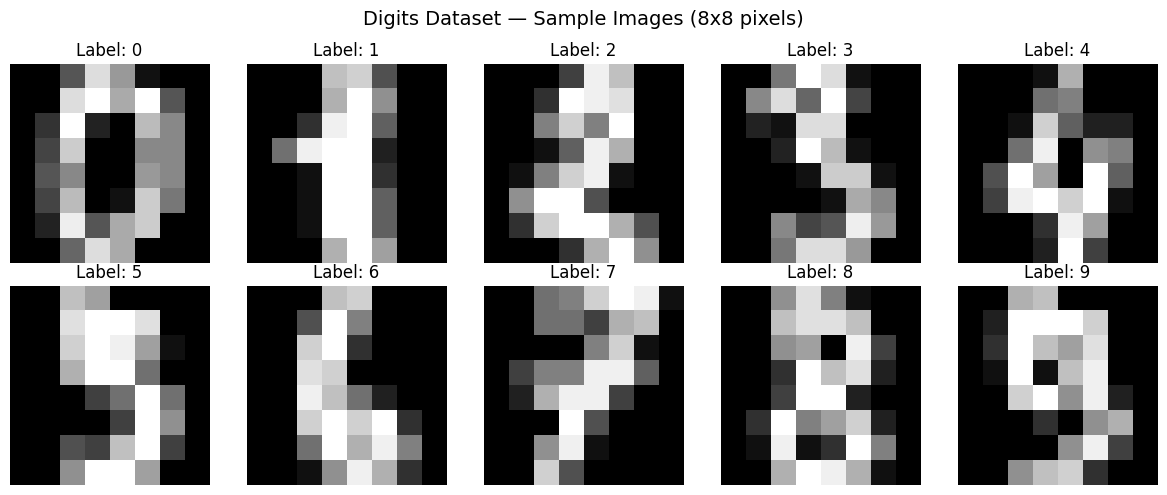

Digit samples saved to digits_knn_samples.png



In [57]:
# another challenge for KNN
from sklearn.datasets import load_digits
digits = load_digits()

print(f"\nDigits dataset shape: {digits.data.shape}")  # (1797, 64)
print(f"Number of classes:    {len(digits.target_names)}")
print(f"Image dimensions:     8x8 pixels = 64 features")
print(f"Pixel value range:    [{digits.data.min():.0f}, {digits.data.max():.0f}]")

# Class distribution
print(f"\nSamples per digit:")
unique, counts = np.unique(digits.target, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} samples")

# visualising sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Digits Dataset — Sample Images (8x8 pixels)', fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('digits_knn_samples.png', dpi=150)
plt.show()
print("Digit samples saved to digits_knn_samples.png\n")

In [58]:
# traning testing split and baseline knn
X_digits = digits.data
y_digits = digits.target

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_d_train)} samples (80%)")
print(f"Test set:     {len(X_d_test)} samples (20%)")

# Baseline with default K=5
knn_digits = KNeighborsClassifier(n_neighbors=5)
knn_digits.fit(X_d_train, y_d_train)
baseline_acc = knn_digits.score(X_d_test, y_d_test)
print(f"\nBaseline accuracy (K=5): {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")

Training set: 1437 samples (80%)
Test set:     360 samples (20%)

Baseline accuracy (K=5): 0.9861 (98.61%)



Results for K=1 to K=20:
  K= 1: Accuracy = 0.9778
  K= 2: Accuracy = 0.9806
  K= 3: Accuracy = 0.9833
  K= 4: Accuracy = 0.9806
  K= 5: Accuracy = 0.9861
  K= 6: Accuracy = 0.9889 ◄ BEST
  K= 7: Accuracy = 0.9889
  K= 8: Accuracy = 0.9861
  K= 9: Accuracy = 0.9806
  K=10: Accuracy = 0.9833
  K=11: Accuracy = 0.9833
  K=12: Accuracy = 0.9778
  K=13: Accuracy = 0.9778
  K=14: Accuracy = 0.9806
  K=15: Accuracy = 0.9778
  K=16: Accuracy = 0.9806
  K=17: Accuracy = 0.9833
  K=18: Accuracy = 0.9806
  K=19: Accuracy = 0.9750
  K=20: Accuracy = 0.9778

Optimal K = 6 with accuracy = 0.9889 (98.89%)


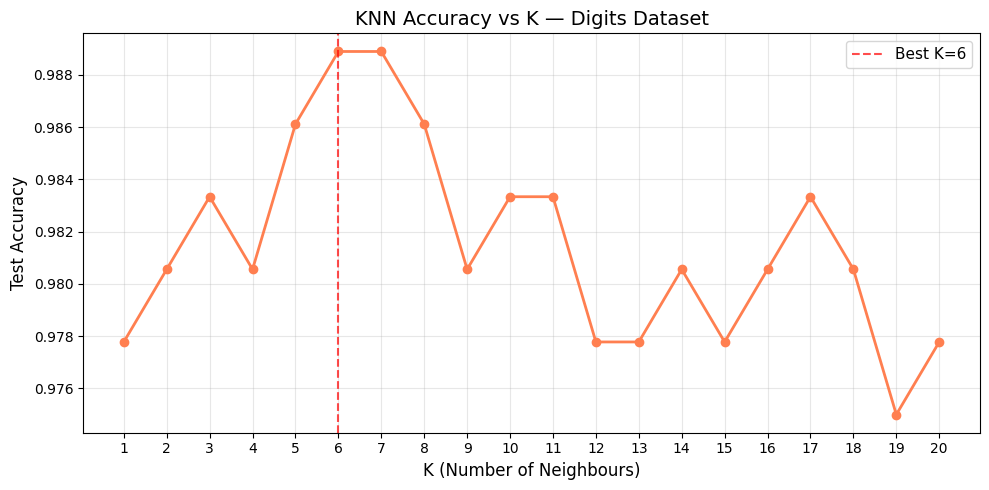

Optimal K plot saved to knn_optimal_k_digits.png



In [59]:
# finding optimal k for digits

k_range_digits = range(1, 21)  # Test K=1 to K=20
k_acc_digits = []

for k in k_range_digits:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_d_train, y_d_train)
    acc = knn_k.score(X_d_test, y_d_test)
    k_acc_digits.append(acc)

best_k_digits = list(k_range_digits)[np.argmax(k_acc_digits)]
best_acc_digits = max(k_acc_digits)

print(f"\nResults for K=1 to K=20:")
for k, acc in zip(k_range_digits, k_acc_digits):
    marker = " ◄ BEST" if k == best_k_digits else ""
    print(f"  K={k:>2}: Accuracy = {acc:.4f}{marker}")

print(f"\nOptimal K = {best_k_digits} with accuracy = "
      f"{best_acc_digits:.4f} ({best_acc_digits*100:.2f}%)")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(list(k_range_digits), k_acc_digits, 'o-', linewidth=2,
         markersize=6, color='coral')
plt.axvline(x=best_k_digits, color='red', linestyle='--', alpha=0.7,
            label=f'Best K={best_k_digits}')
plt.xlabel('K (Number of Neighbours)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('KNN Accuracy vs K — Digits Dataset', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.savefig('knn_optimal_k_digits.png', dpi=150)
plt.show()
print("Optimal K plot saved to knn_optimal_k_digits.png\n")

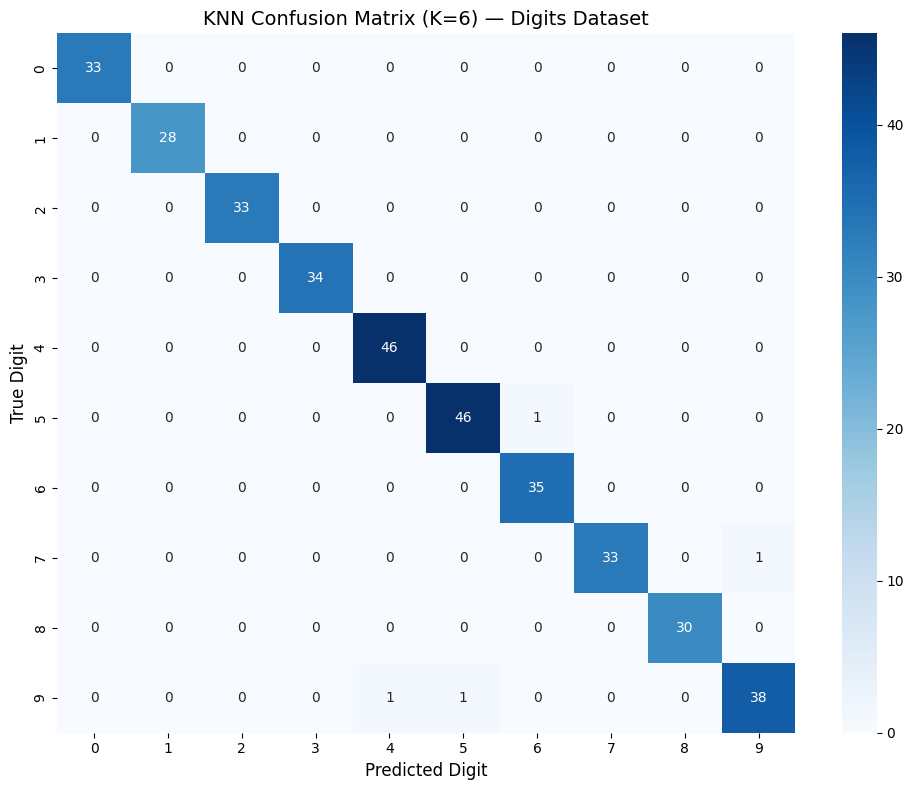

Confusion matrix saved to knn_confusion_matrix_digits.png

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

Misclassified: 4 out of 360 (1.11%)


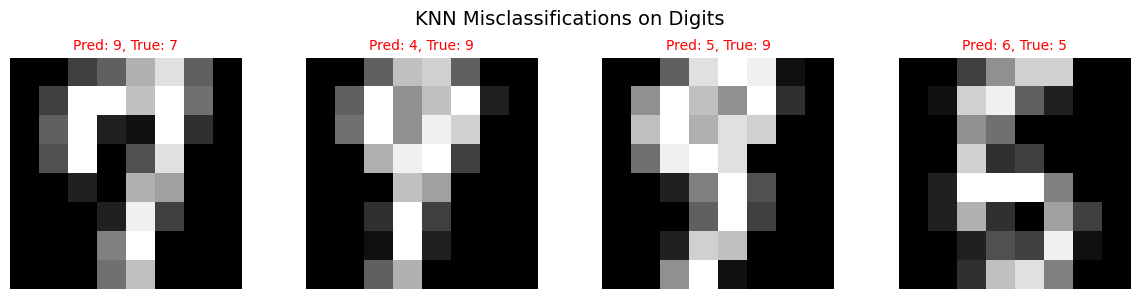

Misclassifications saved to knn_misclassifications_digits.png



In [60]:
# evaluating the best model on digits
# Train final model with optimal K
final_knn = KNeighborsClassifier(n_neighbors=best_k_digits)
final_knn.fit(X_d_train, y_d_train)

y_d_pred = final_knn.predict(X_d_test)

# Confusion Matrix
cm_digits = confusion_matrix(y_d_test, y_d_pred)

plt.figure(figsize=(10, 8))
sn.heatmap(cm_digits, annot=True, fmt='d', cmap='Blues',
           xticklabels=[str(d) for d in range(10)],
           yticklabels=[str(d) for d in range(10)])
plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('True Digit', fontsize=12)
plt.title(f'KNN Confusion Matrix (K={best_k_digits}) — Digits Dataset',
          fontsize=14)
plt.tight_layout()
plt.savefig('knn_confusion_matrix_digits.png', dpi=150)
plt.show()
print("Confusion matrix saved to knn_confusion_matrix_digits.png")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_d_test, y_d_pred,
                            target_names=[str(d) for d in range(10)]))

# Show some misclassified examples
misclassified = np.where(y_d_pred != y_d_test)[0]
print(f"Misclassified: {len(misclassified)} out of {len(y_d_test)} "
      f"({len(misclassified)/len(y_d_test)*100:.2f}%)")

if len(misclassified) > 0:
    fig, axes = plt.subplots(1, min(5, len(misclassified)), figsize=(12, 3))
    fig.suptitle('KNN Misclassifications on Digits', fontsize=14)
    if len(misclassified) == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        if i < len(misclassified):
            idx = misclassified[i]
            ax.imshow(X_d_test[idx].reshape(8, 8), cmap='gray')
            ax.set_title(f"Pred: {y_d_pred[idx]}, True: {y_d_test[idx]}",
                         color='red', fontsize=10)
            ax.axis('off')
    plt.tight_layout()
    plt.savefig('knn_misclassifications_digits.png', dpi=150)
    plt.show()
    print("Misclassifications saved to knn_misclassifications_digits.png\n")


In [62]:
# summary
print(f"""
IRIS DATASET (150 samples, 4 features, 3 classes):
  KNN K=10:                  {accuracy_k10:.4f} ({accuracy_k10*100:.2f}%)
  Best K={best_k}:                 {best_acc:.4f} ({best_acc*100:.2f}%)

DIGITS DATASET (1797 samples, 64 features, 10 classes):
  KNN K=5 (baseline):       {baseline_acc:.4f} ({baseline_acc*100:.2f}%)
  Best K={best_k_digits}:                 {best_acc_digits:.4f} ({best_acc_digits*100:.2f}%)
""")
# This shows that
# KNN achieves approximately 97% accuracy on Iris with K=10. The confusion matrix reveals
#    that Setosa is classified perfectly while
#    Versicolor and Virginica are occasionally confused which demonstrates this behaviour: classification accuracy depends directly on how
#    well separated classes are in feature space.
# KNN achieves high accuracy on digits with optimal K. It shows that KNN works well with similar digits that have similar pixel patterns and if the dataset is clean with no rotation in place
# KNN and SVM achieve similar accuracy on Iris, however, KKN requires no training phase and there is slow prediction while SVM shows slow training but faster prediction.



IRIS DATASET (150 samples, 4 features, 3 classes):
  KNN K=10:                  0.9667 (96.67%)
  Best K=1:                 1.0000 (100.00%)

DIGITS DATASET (1797 samples, 64 features, 10 classes):
  KNN K=5 (baseline):       0.9861 (98.61%)
  Best K=6:                 0.9889 (98.89%)

